## Sistem Rekomendasi Resep Berbasis Content-Based Filtering

**Inisialisasi & Load Data**

### 1. Persiapan Data
Pada tahap ini, kami memuat dataset `clean_recipes.csv` yang telah dibersihkan sebelumnya. Data ini mencakup informasi mengenai nama resep, bahan-bahan, kategori, serta kandungan nutrisi.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
os.chdir("D://project_ets_datmin")

# 2. Cek lokasi saat ini dan list filenya
print("Lokasi aktif sekarang:", os.getcwd())
print("Daftar file di folder ini:", os.listdir())
# Load data hasil cleaning
df = pd.read_csv('clean_recipes.csv')
print(f"Dataset dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.")

Lokasi aktif sekarang: D:\project_ets_datmin
Daftar file di folder ini: ['clean_recipes.csv', 'recommendation_system.ipynb']
Dataset dimuat dengan 14103 baris dan 15 kolom.


**Exploratory Data Analysis (EDA)**

### 2. Analisis Deskriptif (EDA)
Sebelum membangun model, kami melakukan eksplorasi untuk memahami distribusi data, seperti kategori makanan yang paling populer dalam dataset dan sebaran kalori untuk memastikan variasi resep yang tersedia.

C:\Users\Azizah Adilah\AppData\Local\Temp\ipykernel_8648\2319848348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AggregatedRating', palette='Oranges')


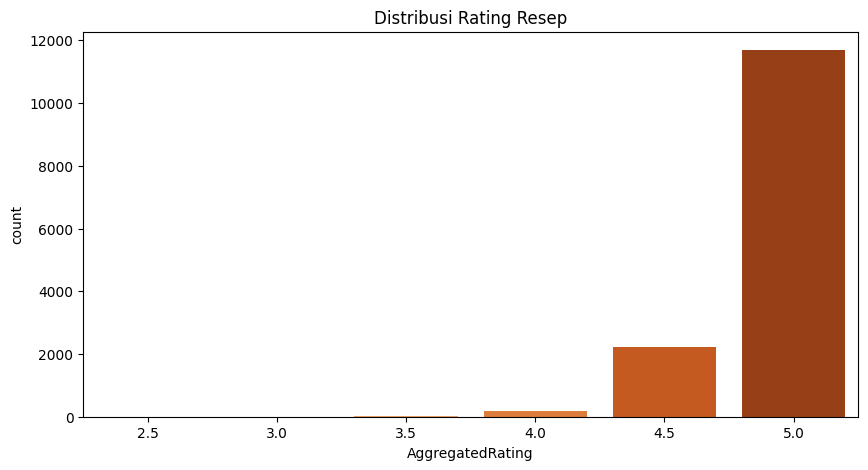

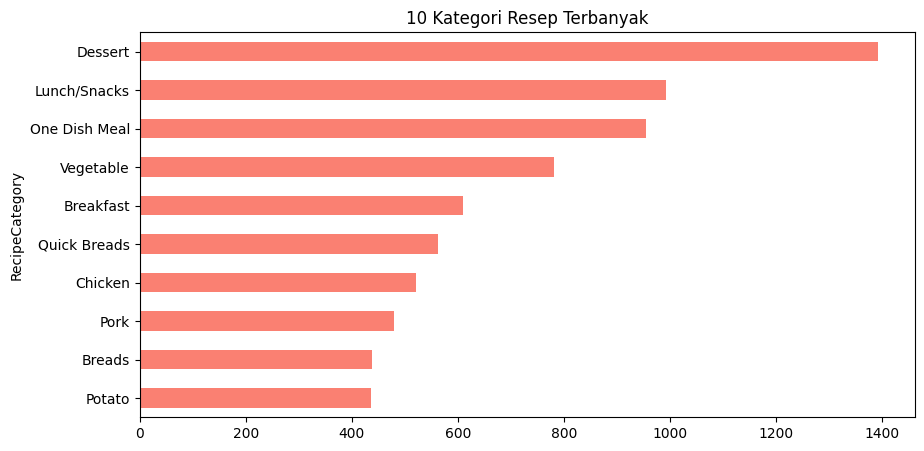

In [2]:
# Visualisasi Distribusi Rating
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='AggregatedRating', palette='Oranges')
plt.title('Distribusi Rating Resep')
plt.show()

# Visualisasi Top 10 Kategori
plt.figure(figsize=(10, 5))
df['RecipeCategory'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title('10 Kategori Resep Terbanyak')
plt.gca().invert_yaxis()
plt.show()

### 3. Pengembangan Model Rekomendasi
Sistem ini menggunakan pendekatan **Content-Based Filtering**. Langkah-langkahnya adalah:

1. **Feature Extraction (TF-IDF):** Mengubah data tekstual pada kolom `Features` menjadi vektor numerik. TF-IDF memberikan bobot lebih pada kata-kata yang spesifik dan unik.
2. **Similarity Measure (Cosine Similarity):** Menghitung sudut kosinus antara dua vektor untuk menentukan seberapa mirip satu resep dengan resep lainnya.



[Image of Content-Based Filtering workflow diagram]

**Feature Engineering untuk Recommendation System**

In [8]:
# Menggabungkan fitur teks untuk dihitung kemiripannya
# gabungkan bahan (Ingredients), kategori, dan kata kunci (Keywords)
df['combined_features'] = df['Features'] + " " + df['RecipeCategory'] + " " + df['Keywords']
df['combined_features'] = df['combined_features'].fillna('')

print("Contoh fitur gabungan untuk baris pertama:")
print(df['combined_features'].iloc[0])

Contoh fitur gabungan untuk baris pertama:
boneless chicken breasts, olive oil, garlic clove, ginger, crushed red pepper flakes, light brown sugar, ketchup, cider vinegar, water, soy sauce, chicken, poultry, meat, chinese, asian, high protein, high in..., < 60 mins, easy Chicken Breast chicken, poultry, meat, chinese, asian, high protein, high in..., < 60 mins, easy


**Membangun model TF-IDF & Cosine Similarity**

In [9]:
# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

# Hitung skor kemiripan antar semua resep
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Matriks Similarity berhasil dibuat dengan ukuran: {cosine_sim.shape}")

Matriks Similarity berhasil dibuat dengan ukuran: (14103, 14103)


**Fungsi Rekomendasi & Uji Coba (Testing)**

In [10]:
def get_recommendations(recipe_name, n=5):
    # Cari index resep berdasarkan nama
    try:
        idx = df[df['Name'].str.contains(recipe_name, case=False)].index[0]
        
        # Ambil skor kemiripan untuk resep tersebut
        sim_scores = list(enumerate(cosine_sim[idx]))
        
        # Urutkan berdasarkan skor tertinggi (abaikan resep itu sendiri di index 0)
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:n+1]
        
        # Ambil index-nya
        recipe_indices = [i[0] for i in sim_scores]
        
        return df.iloc[recipe_indices][['Name', 'RecipeCategory', 'Calories', 'AggregatedRating']]
    except:
        return "Resep tidak ditemukan."

# Uji coba model
print("Hasil Rekomendasi untuk 'Chicken':")
display(get_recommendations('Chicken'))

Hasil Rekomendasi untuk 'Chicken':


,Name,RecipeCategory,Calories,AggregatedRating
2426,Chinese Chicken Wings,Lunch/Snacks,711.7,5.0
3465,Crispy Balsamic Baked Chicken Breasts,Chicken Breast,419.1,4.5
3401,Asian Chicken,Lunch/Snacks,286.2,4.5
8298,Lemon Chicken,Chicken Breast,617.9,5.0
11908,Glazing Your Chicken With Jam and Balsamic - L...,Chicken Breast,305.2,5.0


### 4. Evaluasi Hasil Rekomendasi
Berdasarkan hasil pengujian di atas, sistem berhasil memberikan rekomendasi yang relevan. Misalnya, saat mencari "Chicken", sistem memberikan saran resep lain yang juga memiliki profil bahan dan kategori yang serupa. Hal ini menunjukkan bahwa *Cosine Similarity* bekerja efektif dalam menangkap kemiripan fitur tekstual.